In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


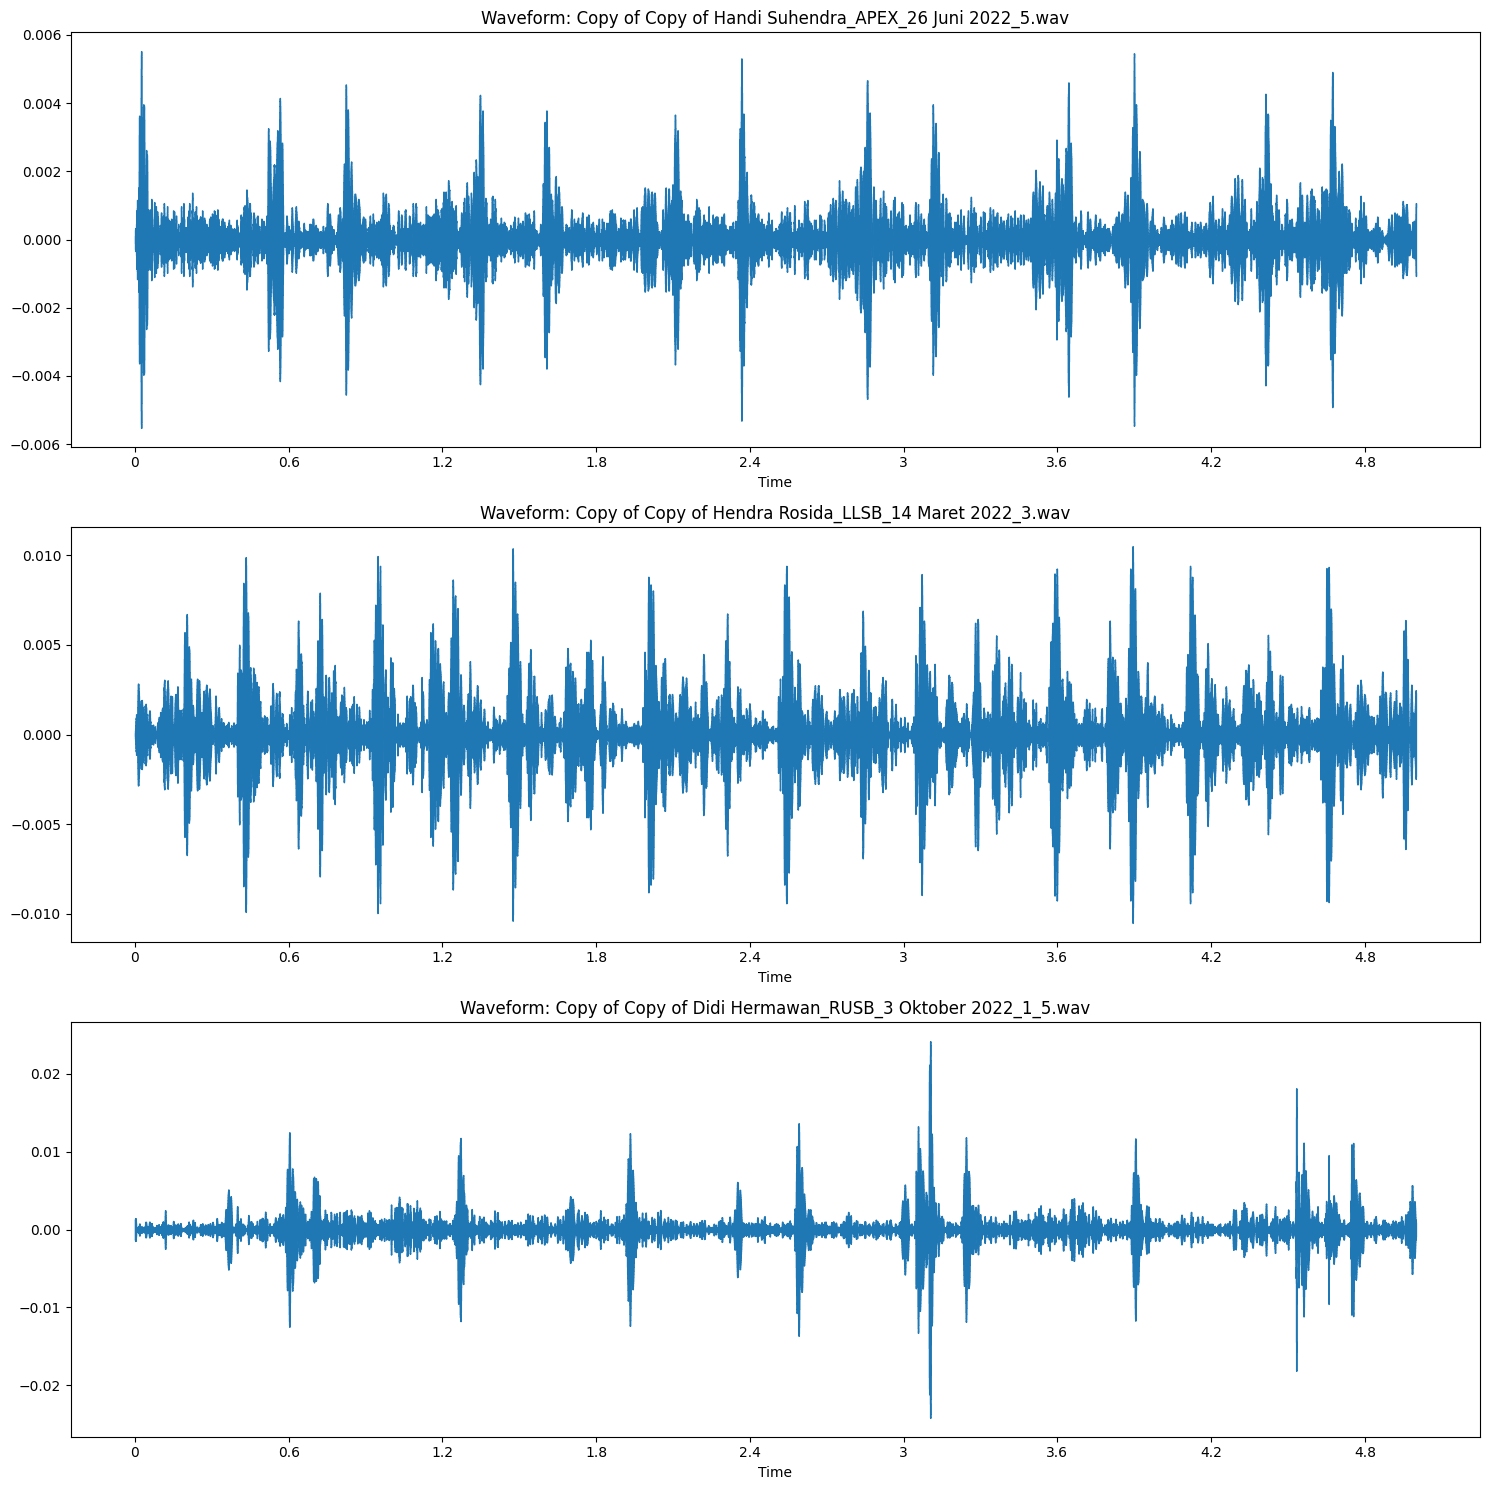

In [2]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/Research 2026/Segmented/myocardial_segment/"
audio_files = [f for f in os.listdir(path) if f.endswith('.wav')]

# Plot the first 3 audio files found
num_to_plot = min(3, len(audio_files))
if num_to_plot == 0:
    print("No .wav files found in the directory.")
else:
    plt.figure(figsize=(15, 5 * num_to_plot))
    for i in range(num_to_plot):
        file_path = os.path.join(path, audio_files[i])
        y, sr = librosa.load(file_path)

        plt.subplot(num_to_plot, 1, i + 1)
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Waveform: {audio_files[i]}")
        plt.tight_layout()
    plt.show()

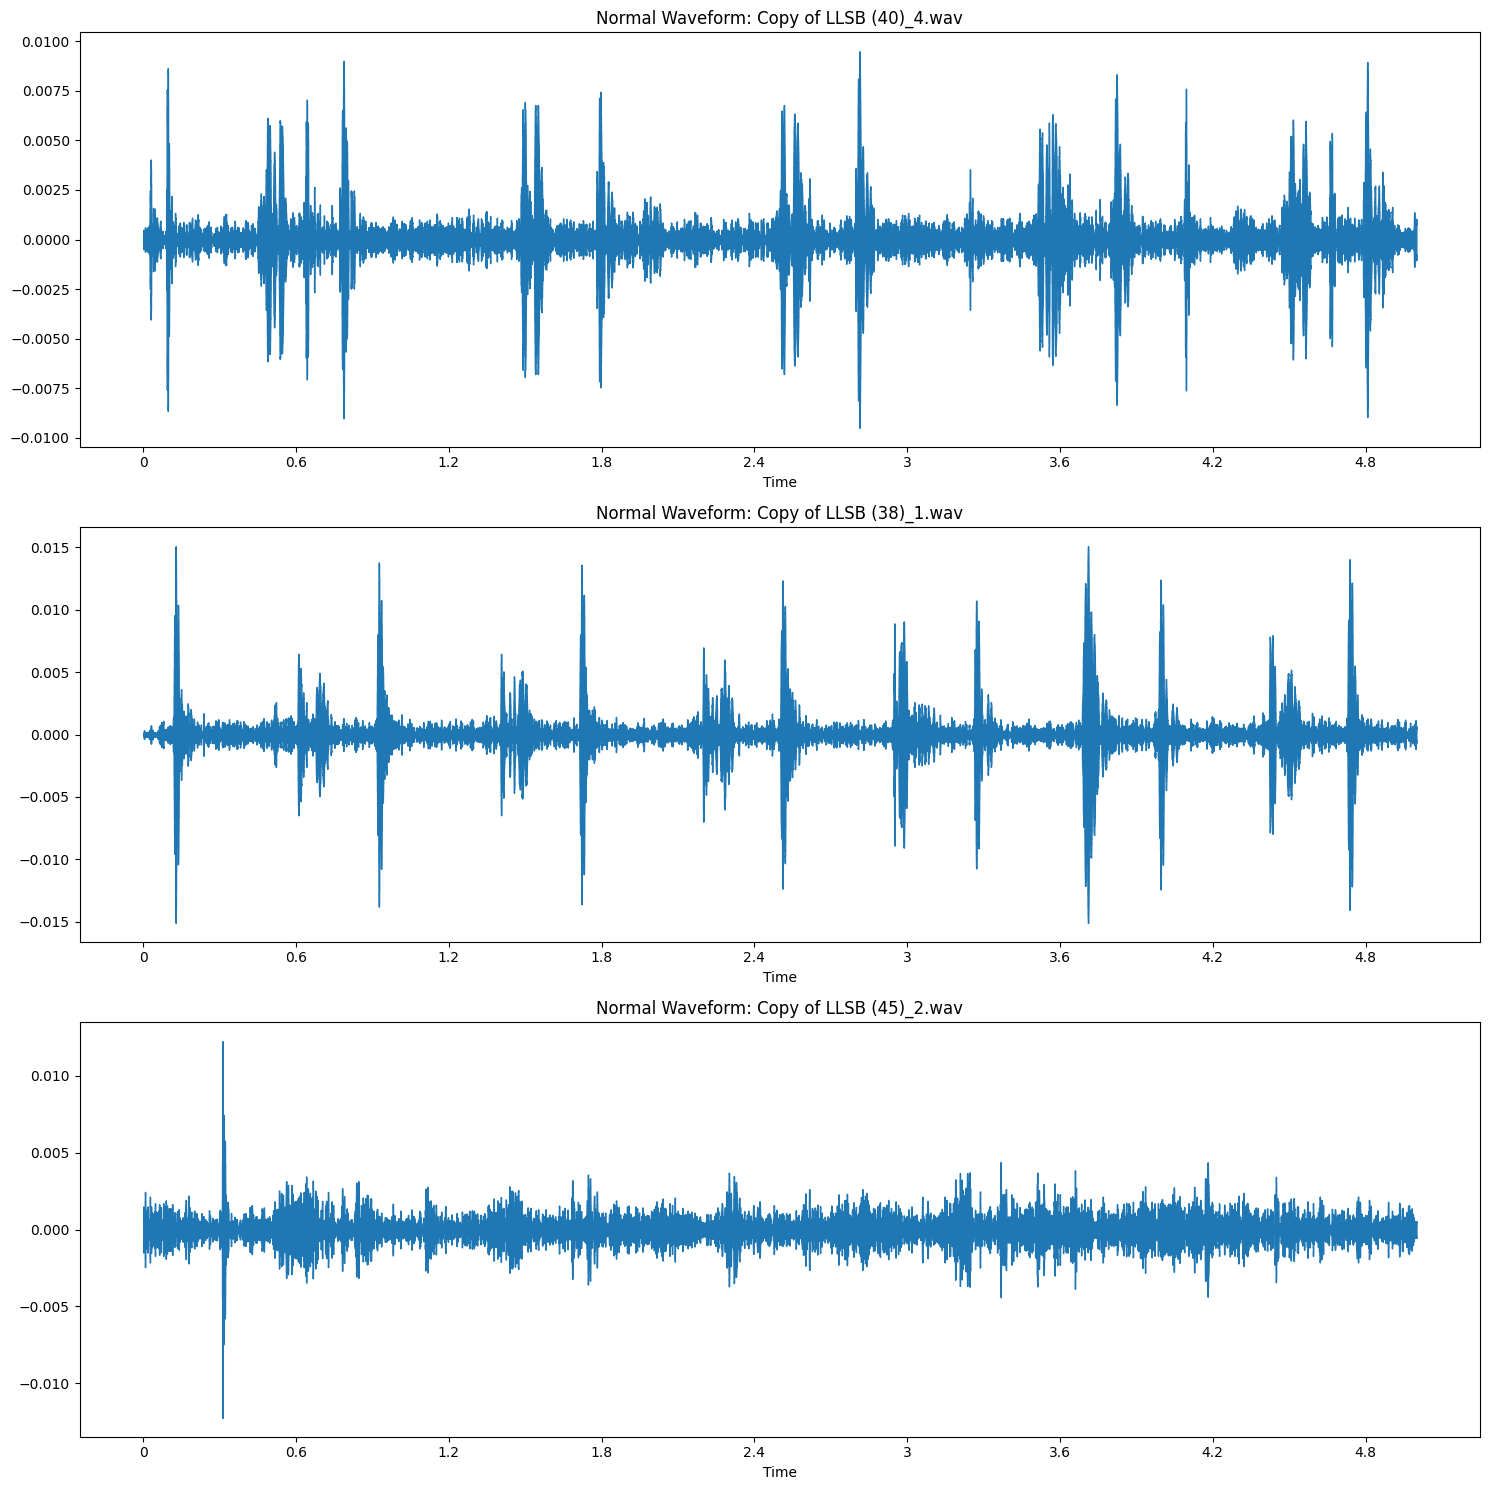

In [3]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Path to the normal segment folder
normal_path = "/content/drive/MyDrive/Research 2026/Segmented/normal_segment/"
normal_audio_files = [f for f in os.listdir(normal_path) if f.endswith('.wav')]

# Plot the first 3 audio files found
num_to_plot = min(3, len(normal_audio_files))
if num_to_plot == 0:
    print("No .wav files found in the 'normal_segment' directory.")
else:
    plt.figure(figsize=(15, 5 * num_to_plot))
    for i in range(num_to_plot):
        file_path = os.path.join(normal_path, normal_audio_files[i])
        y, sr = librosa.load(file_path)

        plt.subplot(num_to_plot, 1, i + 1)
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Normal Waveform: {normal_audio_files[i]}")
        plt.tight_layout()
    plt.show()

In [4]:
import os

paths = [
    "/content/drive/MyDrive/Research 2026/Segmented/normal_segment",
    "/content/drive/MyDrive/Research 2026/Segmented/myocardial_segment"
]

for path in paths:
    try:
        count = len(os.listdir(path))
        print(f"Total files in {path}: {count}")
    except FileNotFoundError:
        print(f"Directory not found: {path}")

Total files in /content/drive/MyDrive/Research 2026/Segmented/normal_segment: 1680
Total files in /content/drive/MyDrive/Research 2026/Segmented/myocardial_segment: 1680


In [5]:
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, duration=3)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        return np.mean(mfccs.T, axis=0)
    except Exception as e:
        return None

# Define paths
normal_path = "/content/drive/MyDrive/Research 2026/Segmented/normal_segment/"
myocardial_path = "/content/drive/MyDrive/Research 2026/Segmented/myocardial_segment/"

features = []
labels = []

# Load Normal samples (Label 0)
print("Extracting features for Normal segments...")
for f in tqdm(os.listdir(normal_path)[:200]):
    if f.endswith('.wav'):
        feat = extract_features(os.path.join(normal_path, f))
        if feat is not None:
            features.append(feat)
            labels.append(0)

# Load myocardial samples (Label 1)
print("Extracting features for myocardial segments...")
for f in tqdm(os.listdir(myocardial_path)[:200]):
    if f.endswith('.wav'):
        feat = extract_features(os.path.join(myocardial_path, f))
        if feat is not None:
            features.append(feat)
            labels.append(1)

X = np.array(features)
y = np.array(labels)

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'myocardial']))

Extracting features for Normal segments...


100%|██████████| 200/200 [00:50<00:00,  3.97it/s]


Extracting features for myocardial segments...


100%|██████████| 200/200 [00:45<00:00,  4.40it/s]



Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.95      0.93        44
  myocardial       0.94      0.89      0.91        36

    accuracy                           0.93        80
   macro avg       0.93      0.92      0.92        80
weighted avg       0.93      0.93      0.92        80



In [6]:
import os
import numpy as np
import librosa
import pandas as pd
from tqdm import tqdm

def extract_segmented_mfccs(file_path, n_mfcc=12):
    try:
        y, sr = librosa.load(file_path, duration=3)
        # Normalizing audio duration to represent a 'standard' cardiac cycle
        # In a real HSMM, these boundaries would come from the model.
        # Here we define typical relative durations: S1(0.12s), Systole(0.3s), S2(0.12s), Diastole(0.46s)
        total_len = len(y)
        s1_end = int(total_len * 0.12)
        systole_end = int(total_len * 0.42)
        s2_end = int(total_len * 0.54)

        segments = {
            's1': y[0:s1_end],
            'systole': y[s1_end:systole_end],
            's2': y[systole_end:s2_end],
            'diastole': y[s2_end:]
        }

        feature_dict = {}
        for seg_name, seg_data in segments.items():
            if len(seg_data) > 0:
                mfccs = librosa.feature.mfcc(y=seg_data, sr=sr, n_mfcc=n_mfcc)
                mfcc_mean = np.mean(mfccs, axis=1)
                for i in range(n_mfcc):
                    feature_dict[f'mfcc_{seg_name}_{i}'] = mfcc_mean[i]
            else:
                for i in range(n_mfcc):
                    feature_dict[f'mfcc_{seg_name}_{i}'] = 0

        return feature_dict
    except Exception as e:
        return None

# Define paths
normal_path = "/content/drive/MyDrive/Research 2026/Segmented/normal_segment/"
myocardial_path = "/content/drive/MyDrive/Research 2026/Segmented/myocardial_segment/"

all_features = []

# Process a subset for demonstration (e.g., 50 from each)
def process_folder(path, label):
    files = [f for f in os.listdir(path) if f.endswith('.wav')][:50]
    for f in tqdm(files, desc=f"Processing {label}"):
        res = extract_segmented_mfccs(os.path.join(path, f))
        if res:
            res['filename'] = f
            res['label'] = label
            all_features.append(res)

process_folder(normal_path, 'Normal')
process_folder(myocardial_path, 'myocardial')

# Create DataFrame to see the mfcc_s1_0...mfcc_diastole_11 columns
df_features = pd.DataFrame(all_features)
print(f"\nExtracted features shape: {df_features.shape}")
print(df_features.head())

Processing myocardial: 100%|██████████| 50/50 [00:02<00:00, 21.84it/s]


Extracted features shape: (100, 50)
    mfcc_s1_0   mfcc_s1_1  mfcc_s1_2  mfcc_s1_3  mfcc_s1_4  mfcc_s1_5  \
0 -793.977600  147.905396  78.708504  41.025330  23.676376  12.827689   
1 -797.852539  152.256302  80.191116  34.862633  17.549850   8.340311   
2 -780.935913  160.416931  88.894409  45.995232  28.377932  15.347906   
3 -795.505371  130.290344  67.966103  40.966717  30.409878  21.718859   
4 -730.616455  180.684677  96.663788  42.794212  13.689816   0.481351   

   mfcc_s1_6  mfcc_s1_7  mfcc_s1_8  mfcc_s1_9  ...  mfcc_diastole_4  \
0  -1.684342  -3.463616   4.871011  14.094645  ...        16.745569   
1  -2.745236  -0.503180  12.113404  22.267017  ...        16.829765   
2  -0.134731  -5.182701   1.842174   6.313895  ...        30.225824   
3   4.516219  -4.066194   0.121476   5.756532  ...        33.572052   
4  -6.878852  -4.500205   6.192576  11.845000  ...        13.067729   

   mfcc_diastole_5  mfcc_diastole_6  mfcc_diastole_7  mfcc_diastole_8  \
0         7.162470      

--- Classification Report (Segmented MFCCs) ---
              precision    recall  f1-score   support

      Normal       0.90      0.90      0.90        10
  myocardial       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20



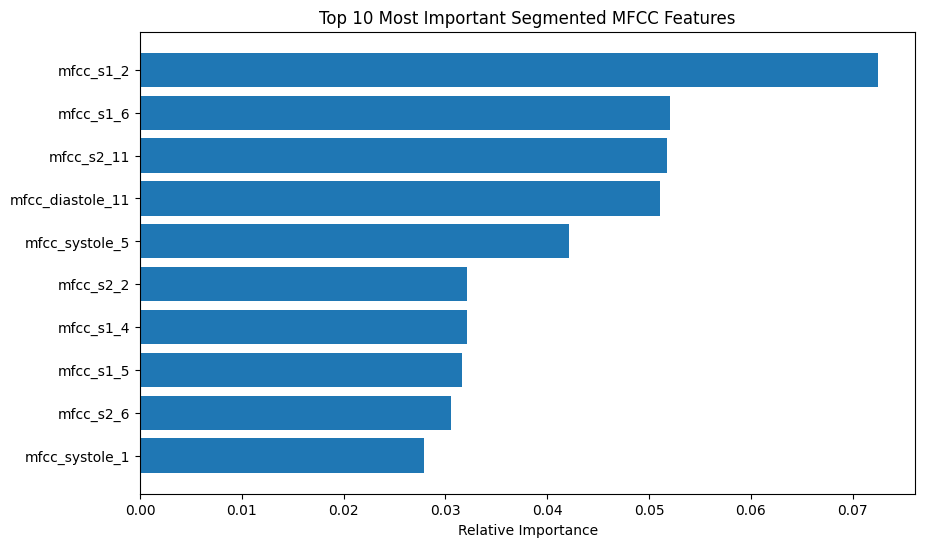

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Data
# We drop 'filename' and 'label' to get the features (X)
# The label column is our target (y)
X_seg = df_features.drop(columns=['filename', 'label'])
y_seg = df_features['label']

# 2. Split into Training and Testing sets
X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(
    X_seg, y_seg, test_size=0.2, random_state=42, stratify=y_seg
)

# 3. Initialize and Train the Classifier
seg_clf = RandomForestClassifier(n_estimators=100, random_state=42)
seg_clf.fit(X_train_seg, y_train_seg)

# 4. Evaluate the Model
y_pred_seg = seg_clf.predict(X_test_seg)

print("--- Classification Report (Segmented MFCCs) ---")
print(classification_report(y_test_seg, y_pred_seg))

# 5. Feature Importance Visualization
importances = seg_clf.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Most Important Segmented MFCC Features')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X_seg.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [8]:
import os
import numpy as np
import librosa
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- 1. Feature Extraction for ALL data ---
all_features_full = []

def process_full_folder(path, label):
    files = [f for f in os.listdir(path) if f.endswith('.wav')]
    for f in tqdm(files, desc=f"Processing all {label} files"):
        res = extract_segmented_mfccs(os.path.join(path, f))
        if res:
            res['filename'] = f
            res['label'] = label
            all_features_full.append(res)

# Clear previous subset data and load everything
process_full_folder(normal_path, 'Normal')
process_full_folder(myocardial_path, 'myocardial')

# Create full DataFrame
df_full = pd.DataFrame(all_features_full)

# --- 2. Machine Learning on Full Dataset ---
X_full = df_full.drop(columns=['filename', 'label'])
y_full = df_full['label']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print("\nTraining model on full dataset...")
clf_full = RandomForestClassifier(n_estimators=100, random_state=42)
clf_full.fit(X_train_full, y_train_full)

# Evaluation
y_pred_full = clf_full.predict(X_test_full)
print("\n--- Final Classification Report (Full Dataset) ---")
print(classification_report(y_test_full, y_pred_full))

print(f"Total samples processed: {len(df_full)}")

Processing all myocardial files: 100%|██████████| 1680/1680 [01:27<00:00, 19.28it/s]



Training model on full dataset...

--- Final Classification Report (Full Dataset) ---
              precision    recall  f1-score   support

      Normal       0.86      0.83      0.85       336
  myocardial       0.84      0.87      0.85       336

    accuracy                           0.85       672
   macro avg       0.85      0.85      0.85       672
weighted avg       0.85      0.85      0.85       672

Total samples processed: 3360


The most important feature is: mfcc_systole_5
Importance score: 0.0534


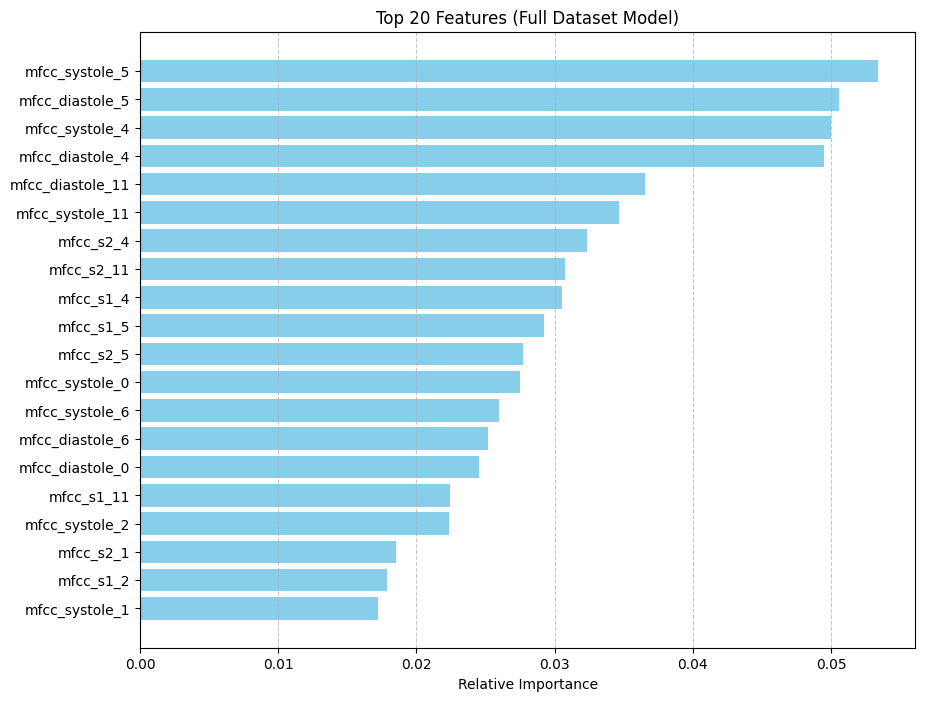

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the full model
importances = clf_full.feature_importances_
feature_names = X_full.columns

# Find the index of the most important feature
most_important_idx = np.argmax(importances)
most_important_feature = feature_names[most_important_idx]
importance_score = importances[most_important_idx]

print(f"The most important feature is: {most_important_feature}")
print(f"Importance score: {importance_score:.4f}")

# Visualize top 20 features for better context
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 8))
plt.title('Top 20 Features (Full Dataset Model)')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()